<a href="https://colab.research.google.com/github/dinusariehewage-coder/ET3112-/blob/main/Q10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

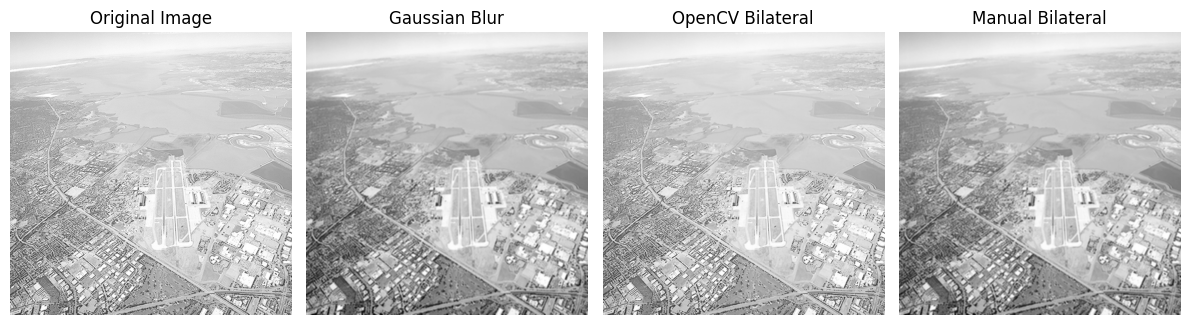

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image_path = '/Assignment 1/runway.png'
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Check image path")

def bilateral_filter_manual(image, d, sigma_s, sigma_r):
    h, w = image.shape
    pad = d // 2
    img_pad = cv.copyMakeBorder(image, pad, pad, pad, pad, cv.BORDER_REFLECT)
    output = np.zeros_like(image, dtype=np.float32)
    ax = np.arange(-pad, pad + 1)
    X, Y = np.meshgrid(ax, ax)
    spatial = np.exp(-(X**2 + Y**2) / (2 * sigma_s**2))
    for i in range(h):
        for j in range(w):
            region = img_pad[i:i+d, j:j+d]
            intensity_diff = region - image[i, j]
            range_kernel = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))
            weights = spatial * range_kernel
            output[i, j] = np.sum(region * weights) / np.sum(weights)
    return output.astype(np.uint8)

d = 5
sigma_s = 3
sigma_r = 25
manual_bilateral = bilateral_filter_manual(img, d, sigma_s, sigma_r)
gaussian = cv.GaussianBlur(img, (d,d), sigmaX=sigma_s)
opencv_bilateral = cv.bilateralFilter(img, d, sigma_r, sigma_s)

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(gaussian, cmap='gray')
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(opencv_bilateral, cmap='gray')
plt.title('OpenCV Bilateral')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(manual_bilateral, cmap='gray')
plt.title('Manual Bilateral')
plt.axis('off')

plt.tight_layout()
plt.show()
